In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class SpeakerEncoderConfig:
    sample_rate: int = 16000
    n_mels: int= 40
    n_fft: int=512
    hop_length: int= 160
    win_length: int=400
    partial_n_frames: int=160
    lstm_hidden: int=768
    lstm_layers: int=3
    embedding_dim: int=256
    speakers_per_batch: int=64
    utterances_per_speaker: int=10
    ge2e_init_w: float=10.0
    ge2e_init_b: float=-5.0
cfg=SpeakerEncoderConfig()
print("Speaker Encoder Config:")
print(f"  Input:          {cfg.n_mels} mel bins @ {cfg.sample_rate}Hz")
print(f"  LSTM:           {cfg.lstm_layers} layers × {cfg.lstm_hidden} hidden units")
print(f"  Embedding:      {cfg.embedding_dim} dimensions")
print(f"  Training batch: {cfg.speakers_per_batch} speakers × {cfg.utterances_per_speaker} utterances")
print(f"  Partial clip:   {cfg.partial_n_frames} frames = {cfg.partial_n_frames * cfg.hop_length / cfg.sample_rate * 1000:.0f}ms")

Speaker Encoder Config:
  Input:          40 mel bins @ 16000Hz
  LSTM:           3 layers × 768 hidden units
  Embedding:      256 dimensions
  Training batch: 64 speakers × 10 utterances
  Partial clip:   160 frames = 1600ms


In [1]:
class SpeakerMelSpectrogram(nn.Module):
    def __init__(self, config: SpeakerEncoderConfig=cfg):
        super().__init__()
        self.config=config
        self.register_buffer("window",torch.hann_window(config.win_length))
        filterbank=self._build_filterbank()
        self.register_buffer("filterbank",filterbank)
    def _build_filterbank(self)->torch.Tensor:
        cfg=self.config
        def hz_to_mel(hz): return 2595.0*np.log10(1.0+hz/700.0)
        def mel_to_hz(mel): return 700.0*(10.0**(mel/2595.0)-1.0)
        n_freq=cfg.n_fft//2+1
        fft_freqs=np.linspace(0,cfg.sample_rate/2,n_freq)
        mel_min=hz_to_mel(0.0)
        mel_max=hz_to_mel(cfg.sample_rate/2)
        mel_pts=np.linspace(mel_min,mel_max,cfg.n_mels+2)
        hz_pts=np.array([mel_to_hz(m) for m in mel_pts])
        bins=np.searchsorted(fft_freqs,hz_pts)
        fb=np.zeros((cfg.n_mels,n_freq),dtype=np.float32)
        for m in range(1, cfg.n_mels+1):
            left,centre,right=bins[m-1],bins[m],bins[m+1]
            for k in range(left, centre):
                if centre!=left:
                    fb[m-1,k]=(k-left)/(centre-left)
            for k in range(centre,right):
                if right != centre:
                    fb[m-1,k]=(right - k)/(right - centre)
        return torch.FloatTensor(fb)
    def forward(self, waveform: torch.Tensor)-> torch.Tensor:
        if waveform.dim()==1:
            waveform=waveform.unsqueeze(0)
        batch_size=waveform.shape[0]
        results=[]
        for i in range(batch_size):
            stft=torch.stft(
                waveform[i],
                n_fft=self.config.n_fft,
                hop_length=self.config.hop_length,
                win_length=self.config.win_length,
                window=self.window,
                center=True,
                onesided=True,
                normalized=False,
                return_complex=True
            )
            power=torch.abs(stft)**2
            mel=torch.matmul(self.filterbank,power)
            log_mel=torch.log(mel+1e-5)
            results.append(log_mel)
        return torch.stack(results, dim=0)
mel_fn   = SpeakerMelSpectrogram()
dummy    = torch.randn(2, 16000)   # batch of 2, one second each at 16kHz
log_mels = mel_fn(dummy)

print(f"Input waveform shape:  {dummy.shape}      [batch=2, samples=16000]")
print(f"Output mel shape:      {log_mels.shape}  [batch=2, n_mels=40, time_frames]")
print(f"One frame = {cfg.hop_length / cfg.sample_rate * 1000:.1f}ms")
print(f"Frames for 1 second = {log_mels.shape[2]}")

NameError: name 'nn' is not defined

In [ ]:
class SpeakerEncoder(nn.Module):
    def __init__(self,config:SpeakerEncoderConfig=cfg):
        super().__init__()
        self.config=config
        self.lstm=nn.LSTM(
            input_size=config.n_mels,
            hidden_size=config.lstm_hidden,
            num_layers=config.lstm_layers,
            batch_first=True,
        )
        self.projection=nn.Linear(config.lstm_hidden,config.embedding_dim)
    def forward(self,mel: torch.Tensor)->torch.Tensor:
        mel_transposed=mel.transpose(1,2)
        outputs, (h_n,c_n)=self.lstm(mel_transposed)
        final_hidden=h_n[-1]
        embedding=self.projection(final_hidden)
        embedding=F.normalize(embedding,p=2,dim=1)
        return embedding
    def embed_utterance(self, mel: torch.Tensor,overlap: float=0.5)->torch.Tensor:
        n_frame=mel.shape[2]
        frame_step=cfg.partial_n_frames
        hop=int(frame_step*(1-overlap))
        if n_frame<= frame_step:
            return self.forward(mel)[0]
        embeddings=[]
        start=0
        while start+frame_step<=n_frame:
            chunk=mel[:, :, start: start+frame_step]
            emb=self.forward(chunk)[0]
            embeddings.append(emb)
            start+=hop
        embeddings=torch.stack(embeddings,dim=0)
        mean_emb=embeddings.mean(dim=0)
        return F.normalize(mean_emb,p=2,dim=0)
encoder = SpeakerEncoder(cfg)

print("SpeakerEncoder architecture:")
print(encoder)
print()

# Count parameters
total_params = sum(p.numel() for p in encoder.parameters())
print(f"Total parameters: {total_params:,}")
print(f"  LSTM:       {sum(p.numel() for p in encoder.lstm.parameters()):,}")
print(f"  Projection: {sum(p.numel() for p in encoder.projection.parameters()):,}")

SpeakerEncoder architecture:
SpeakerEncoder(
  (lstm): LSTM(40, 768, num_layers=3, batch_first=True)
  (projection): Linear(in_features=768, out_features=256, bias=True)
)

Total parameters: 12,134,656
  LSTM:       11,937,792
  Projection: 196,864


In [ ]:
class GE2ELoss(nn.Module):
    def __init__(self,config: SpeakerEncoderConfig=cfg):
        super().__init__()
        self.w=nn.Parameter(torch.tensor(config.ge2e_init_w))
        self.b=nn.Parameter(torch.tensor(config.ge2e_init_b))
    def forward(self,embeddings: torch.Tensor)-> torch.Tensor:
        N=cfg.speakers_per_batch
        M=cfg.utterances_per_speaker
        D=embeddings.shape[1]
        embeddings=embeddings.reshape(N,M,D)
        centroids=embeddings.mean(dim=1)
        similarity=torch.zeros(N,M,N,device=embeddings.device)
        for n in range(N):
            for m in range(M):
                for j in range(N):
                    if j==n:
                        centroid_loo=(centroids[n]*M-embeddings[n,m])/(M-1)
                        sim=F.cosine_similarity(
                            embeddings[n,m].unsqueeze(0),
                            centroid_loo.unsqueeze(0)
                        )
                    else:
                        sim=F.cosine_similarity(
                            embeddings[n,m].unsqueeze(0),
                            centroids[j].unsqueeze(0)
                        )
                    similarity[n,m,j]=sim
        w=self.w.clamp(min=0.001)
        similarity=w*similarity+self.b
        similarity_flat=similarity.reshape(N*M,N)
        labels=torch.arange(N,device=embeddings.device)
        labels=labels.repeat_interleave(M)
        loss=F.cross_entropy(similarity_flat,labels)
        return loss
ge2e = GE2ELoss(cfg)

# Simulate what we'd get from the encoder during training.
# N*M random unit-normalized embeddings.
N, M, D = cfg.speakers_per_batch, cfg.utterances_per_speaker, cfg.embedding_dim
dummy_embeddings = F.normalize(torch.randn(N * M, D), p=2, dim=1)

loss = ge2e(dummy_embeddings)

print(f"GE2E Loss test:")
print(f"  Input: {dummy_embeddings.shape}  [N×M={N*M} embeddings, D={D}]")
print(f"  Loss:  {loss.item():.4f}")
print()
print(f"Interpretation:")
print(f"  Random embeddings → loss ≈ log({N}) = {np.log(N):.3f}  (chance level)")
print(f"  Computed loss: {loss.item():.3f}  (should be close to {np.log(N):.3f})")
print(f"  After training: loss will drop as embeddings become discriminative")

GE2E Loss test:
  Input: torch.Size([640, 256])  [N×M=640 embeddings, D=256]
  Loss:  4.2883

Interpretation:
  Random embeddings → loss ≈ log(64) = 4.159  (chance level)
  Computed loss: 4.288  (should be close to 4.159)
  After training: loss will drop as embeddings become discriminative


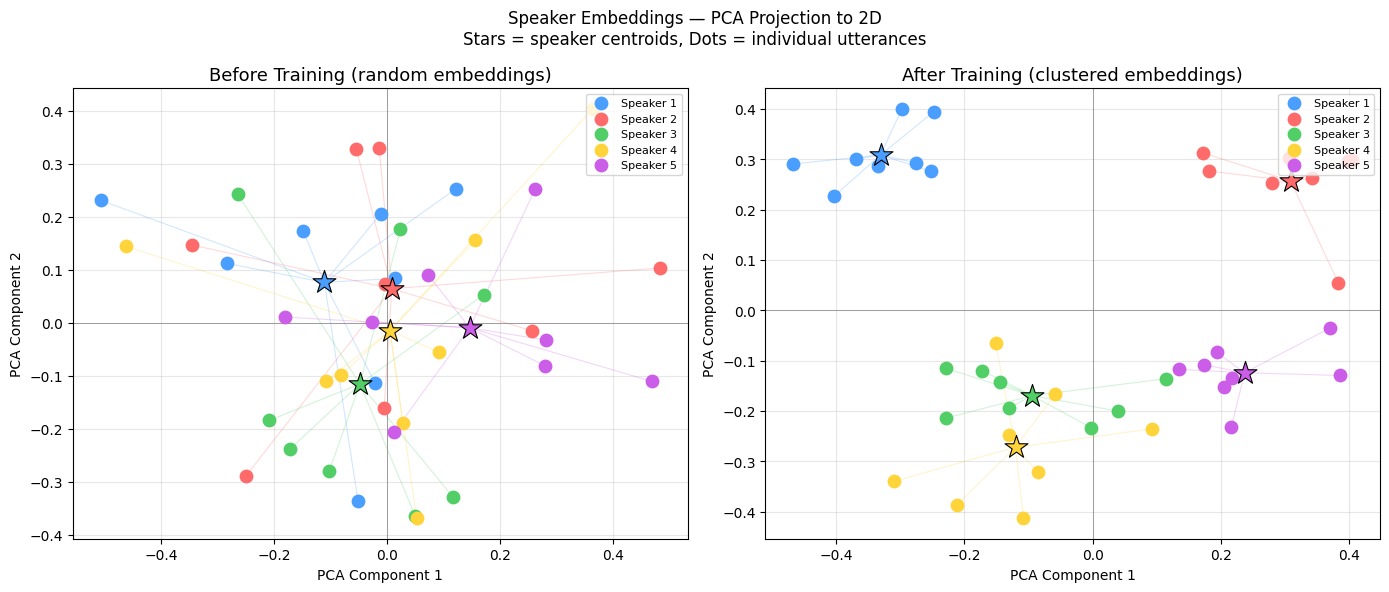

Left plot:  random embeddings — no speaker structure (what you start with)
Right plot: clustered embeddings — what GE2E loss trains toward

After training, same-speaker utterances cluster tightly.
The encoder has learned to extract vocal identity regardless of content.


In [ ]:
from sklearn.decomposition import PCA
n_speakers=5
n_utterances=8
D=cfg.embedding_dim
before=F.normalize(torch.randn(n_speakers*n_utterances,D),p=2,dim=1)
speaker_centroid=F.normalize(torch.randn(n_speakers,D),p=2,dim=1)
noise_scale=0.15
after_list=[]
for i in range(n_speakers):
    for _ in range(n_utterances):
        noisy=speaker_centroid[i]+torch.randn(D)*noise_scale
        after_list.append(F.normalize(noisy,p=2,dim=0))
after=torch.stack(after_list)
pca=PCA(n_components=2)
before_2d=pca.fit_transform(before.detach().numpy())
after_2d=pca.fit_transform(after.detach().numpy())
colors = ["#4a9eff", "#ff6b6b", "#51cf66", "#ffd43b", "#cc5de8"]
labels_list = [f"Speaker {i+1}" for i in range(n_speakers)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, embeddings_2d, title in zip(
    axes,
    [before_2d, after_2d],
    ["Before Training (random embeddings)", "After Training (clustered embeddings)"]
):
    for i in range(n_speakers):
        start = i * n_utterances
        end   = start + n_utterances
        pts   = embeddings_2d[start:end]

        # Plot utterances as dots
        ax.scatter(pts[:, 0], pts[:, 1],
                   color=colors[i], s=80, zorder=3, label=labels_list[i])

        # Plot centroid as a star
        centroid = pts.mean(axis=0)
        ax.scatter(centroid[0], centroid[1],
                   color=colors[i], marker="*", s=300, zorder=4,
                   edgecolors="black", linewidths=0.8)

        # Draw lines from each utterance to its centroid
        for pt in pts:
            ax.plot([pt[0], centroid[0]], [pt[1], centroid[1]],
                    color=colors[i], alpha=0.25, linewidth=0.8)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.suptitle("Speaker Embeddings — PCA Projection to 2D\n"
             "Stars = speaker centroids, Dots = individual utterances",
             fontsize=12)
plt.tight_layout()
plt.show()

print("Left plot:  random embeddings — no speaker structure (what you start with)")
print("Right plot: clustered embeddings — what GE2E loss trains toward")
print()
print("After training, same-speaker utterances cluster tightly.")
print("The encoder has learned to extract vocal identity regardless of content.")

In [ ]:
mel_fn=SpeakerMelSpectrogram(cfg)
encoder=SpeakerEncoder(cfg)
n_speakers=3
n_utterances=4
clip_samples=16000*2
print("Forward pass test:")
print("-" * 50)
all_embeddings=[]
for spk in range(n_speakers):
    for utt in range(n_utterances):
        waveform=torch.randn(1,clip_samples)
        mel=mel_fn(waveform)
        if mel.shape[2]>cfg.partial_n_frames:
            start = torch.randint(0, mel.shape[2] - cfg.partial_n_frames, (1,)).item()
            mel_crop=mel[:,:,start:start+cfg.partial_n_frames]
        else:
            mel_crop=mel
        embedding=encoder(mel_crop)
        all_embeddings.append(embedding)
all_embeddings=torch.cat(all_embeddings,dim=0)

print(f"Batch: {n_speakers} speakers × {n_utterances} utterances = {n_speakers*n_utterances} clips")
print(f"Each clip: {clip_samples} samples = {clip_samples/16000:.1f}s at 16kHz")
print(f"Mel shape per clip: [1, {cfg.n_mels}, {cfg.partial_n_frames}]")
print(f"Embedding per clip: [1, {cfg.embedding_dim}]")
print(f"All embeddings:     {all_embeddings.shape}")
print()
norms=all_embeddings.norm(dim=1)
print(f"Embedding norms (should all be 1.0):")
print(f"  min={norms.min():.6f}  max={norms.max():.6f}  mean={norms.mean():.6f}")
print()
sim_matrix=torch.matmul(all_embeddings,all_embeddings.T)
print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"  (diagonal = self-similarity = 1.0 since L2 normalized)")
print(f"  Diagonal mean: {sim_matrix.diagonal().mean():.4f}  (expect 1.0)")
print(f"  Off-diagonal mean: {(sim_matrix.sum() - sim_matrix.diagonal().sum()) / (sim_matrix.numel() - len(sim_matrix)):.4f}  (random ≈ 0)")

Forward pass test:
--------------------------------------------------
Batch: 3 speakers × 4 utterances = 12 clips
Each clip: 32000 samples = 2.0s at 16kHz
Mel shape per clip: [1, 40, 160]
Embedding per clip: [1, 256]
All embeddings:     torch.Size([12, 256])

Embedding norms (should all be 1.0):
  min=1.000000  max=1.000000  mean=1.000000

Similarity matrix shape: torch.Size([12, 12])
  (diagonal = self-similarity = 1.0 since L2 normalized)
  Diagonal mean: 1.0000  (expect 1.0)
  Off-diagonal mean: 0.9992  (random ≈ 0)


In [ ]:
print("Week 3 Summary — Speaker Encoder")
print("=" * 60)
print()
print("What we built:")
print()
print("  SpeakerMelSpectrogram")
print("    16kHz audio → 40-bin log mel spectrogram")
print("    Same logic as Week 1 but tuned for speaker ID")
print()
print("  SpeakerEncoder")
print("    mel [batch, 40, T] → embedding [batch, 256]")
print("    3-layer LSTM (768 hidden) + linear projection + L2 normalize")
print("    embed_utterance(): handles arbitrary-length audio via windowing")
print()
print("  GE2ELoss")
print("    Trains encoder to cluster same-speaker embeddings")
print("    Leave-one-out centroids prevent trivial solutions")
print("    Starts at loss ≈ log(N), drops as embeddings become discriminative")
print()
print("How it connects to the full system:")
print("  encoder(your_voice_audio) → [256]  ← your vocal identity")
print("  acoustic_model(phonemes, speaker_embedding=[256]) → mel spectrogram")
print("  vocoder(mel) → audio in your voice")
print()
print("Next: Week 4 — Acoustic Model (FastSpeech2-style)")
print("  Takes: phoneme token sequence + speaker embedding")
print("  Gives: mel spectrogram in the target speaker's voice")

Week 3 Summary — Speaker Encoder

What we built:

  SpeakerMelSpectrogram
    16kHz audio → 40-bin log mel spectrogram
    Same logic as Week 1 but tuned for speaker ID

  SpeakerEncoder
    mel [batch, 40, T] → embedding [batch, 256]
    3-layer LSTM (768 hidden) + linear projection + L2 normalize
    embed_utterance(): handles arbitrary-length audio via windowing

  GE2ELoss
    Trains encoder to cluster same-speaker embeddings
    Leave-one-out centroids prevent trivial solutions
    Starts at loss ≈ log(N), drops as embeddings become discriminative

How it connects to the full system:
  encoder(your_voice_audio) → [256]  ← your vocal identity
  acoustic_model(phonemes, speaker_embedding=[256]) → mel spectrogram
  vocoder(mel) → audio in your voice

Next: Week 4 — Acoustic Model (FastSpeech2-style)
  Takes: phoneme token sequence + speaker embedding
  Gives: mel spectrogram in the target speaker's voice
